# 🕵️ Detecção de Fraudes em Transações de Cartão de Crédito

Projeto do desafio de **detecção de fraude com dados desbalanceados**.

**Fluxo do notebook**

1. **Explorar** - carregar a base, entender as colunas e medir a proporção de fraudes  
2. **Preparar** - criar variáveis, separar treino/teste com `stratify` e padronizar com `StandardScaler`  
3. **Treinar** - Regressão Logística (baseline), Random Forest e XGBoost com peso de classes  
4. **Avaliar** - relatório de classificação, curva ROC e curva de precisão x recall (foco no **recall da fraude**)  
5. **Ajustar o limiar** de decisão sem "espiar" o teste  
6. **Comparar** undersampling x oversampling x peso de classes  
7. **Explicar** - importância das variáveis e **SHAP**

> **Por que não usar acurácia?** Com 99,8% de transações normais, um modelo que responde
> "não é fraude" para tudo acerta ~99,8% e não detecta nenhuma fraude. Por isso o foco é
> **recall** (quantas fraudes eu peguei), **precisão** (dos alertas, quantos eram fraude de verdade) e **F1**.

## 0. Configuração do ambiente

In [1]:
%pip install -q shap xgboost

In [2]:
import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, classification_report,
                             ConfusionMatrixDisplay, confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_predict,
                                     train_test_split)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import shap

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# parâmetros do projeto
SEED = 42
DATA_URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
RECALL_ALVO = 0.85
EXECUTAR_GRID = True

os.makedirs("imagens", exist_ok=True)
os.makedirs("resultados", exist_ok=True)

def salvar(nome):
    """Salva a figura atual em imagens/ (chamar ANTES do plt.show())."""
    plt.savefig(f"imagens/{nome}.png", dpi=150, bbox_inches="tight")

## 1. Explorar os dados

A base tem `Time` (segundos desde a 1ª transação), `Amount` (valor), `Class` (0 = normal, 1 = fraude)
e `V1`-`V28`, variáveis anonimizadas por **PCA** para proteger a privacidade.
O dataset é carregado **pelo link** (não fica no repositório).

In [3]:
df = pd.read_csv(DATA_URL)
print("Formato:", df.shape)
display(df.head())
print("Valores nulos:", int(df.isna().sum().sum()), "| Linhas duplicadas:", int(df.duplicated().sum()))
df.info()

Formato: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


Valores nulos: 0 | Linhas duplicadas: 1081
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20  

### 1.1 Proporção de fraudes

,transações,percentual (%)
Normal (0),284315,99.8273
Fraude (1),492,0.1727


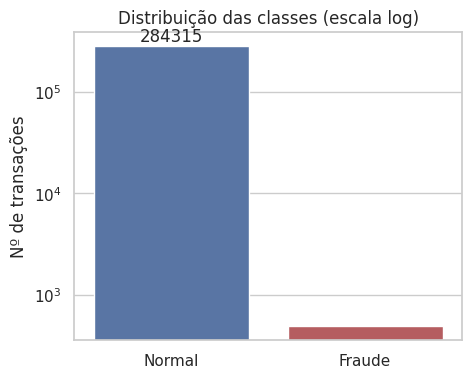

In [4]:
contagem = df["Class"].value_counts().sort_index()
percentual = df["Class"].value_counts(normalize=True).sort_index() * 100
resumo_classes = pd.DataFrame({"transações": contagem, "percentual (%)": percentual})
resumo_classes.index = ["Normal (0)", "Fraude (1)"]
display(resumo_classes)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=["Normal", "Fraude"], y=contagem.values, ax=ax, palette=["#4C72B0", "#C44E52"])
ax.set_yscale("log")
ax.bar_label(ax.containers[0], fmt="%d")
ax.set_title("Distribuição das classes (escala log)")
ax.set_ylabel("Nº de transações")
salvar("01_distribuicao_classes")
plt.show()

### 1.2 Valor e horário: fraudes se comportam diferente?

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,"284,315.0000",88.2910,250.1051,0.0000,5.6500,22.0000,77.0500,"25,691.1600"
1,492.0000,122.2113,256.6833,0.0000,1.0000,9.2500,105.8900,"2,125.8700"


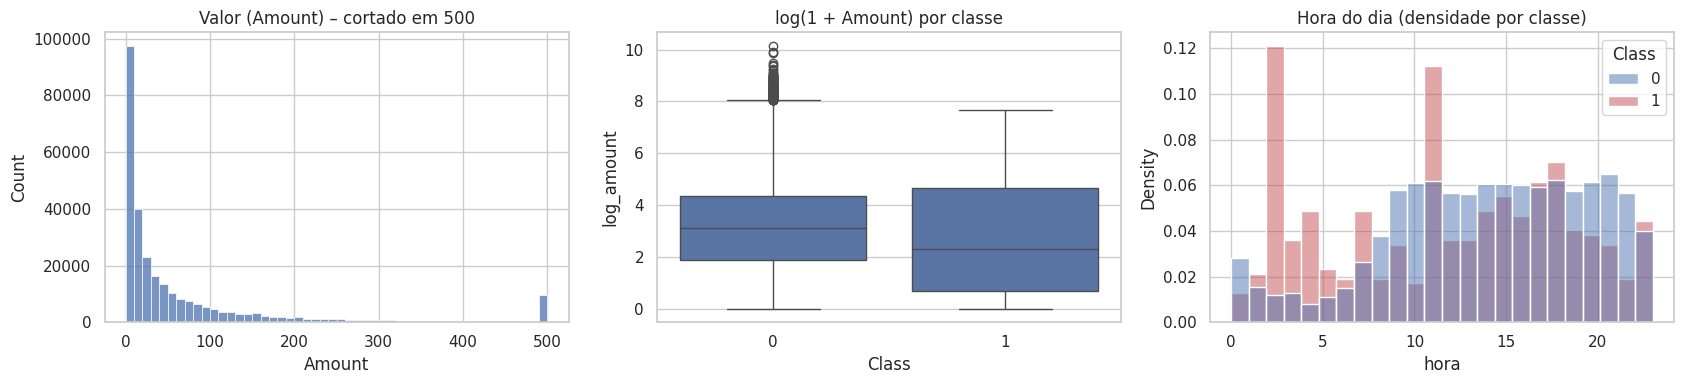

In [5]:
display(df.groupby("Class")["Amount"].describe())

exploracao = df.assign(log_amount=np.log1p(df["Amount"]), hora=(df["Time"] // 3600) % 24)

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(exploracao["Amount"].clip(upper=500), bins=50, ax=ax[0])
ax[0].set_title("Valor (Amount) – cortado em 500")
sns.boxplot(data=exploracao, x="Class", y="log_amount", ax=ax[1])
ax[1].set_title("log(1 + Amount) por classe")
sns.histplot(data=exploracao, x="hora", hue="Class", bins=24, stat="density",
             common_norm=False, ax=ax[2], palette=["#4C72B0", "#C44E52"])
ax[2].set_title("Hora do dia (densidade por classe)")
plt.tight_layout()
salvar("02_exploracao_valor_hora")
plt.show()

**Leitura:** `Amount` tem cauda longa (poucos valores muito altos), por isso o **log** deixa a variável
mais bem comportada. A distribuição por hora mostra se há períodos em que a fraude é relativamente mais comum.

## 2. Preparar os dados

Decisões:

- Remover **duplicatas** (evita a mesma transação cair em treino e teste).
- Criar `log_amount` (log do valor) e `hora` (hora do dia a partir de `Time`).
- Separar treino/teste com **`stratify=y`**, mantendo a proporção de fraudes nos dois.
- Padronizar com `StandardScaler` **ajustado só no treino** (ajustar antes de separar vazaria informação do teste).

In [6]:
df_modelo = df.drop_duplicates().reset_index(drop=True)
df_modelo["log_amount"] = np.log1p(df_modelo["Amount"])
df_modelo["hora"] = (df_modelo["Time"] // 3600) % 24

FEATURES = [f"V{i}" for i in range(1, 29)] + ["log_amount", "hora"]
X = df_modelo[FEATURES]
y = df_modelo["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print(f"Removidas {len(df) - len(df_modelo)} linhas duplicadas")
print(f"Treino: {X_train.shape} | fraudes: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Teste : {X_test.shape} | fraudes: {y_test.sum()} ({y_test.mean()*100:.3f}%)")

scaler = StandardScaler().fit(X_train)
X_train = pd.DataFrame(scaler.transform(X_train), columns=FEATURES, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=FEATURES, index=X_test.index)

Removidas 1081 linhas duplicadas
Treino: (226980, 30) | fraudes: 378 (0.167%)
Teste : (56746, 30) | fraudes: 95 (0.167%)


## 3. Por que a acurácia engana: o modelo que sempre diz "não é fraude"

In [7]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

print(f"Acurácia : {accuracy_score(y_test, pred_dummy):.4f}   <- parece ótima")
print(f"Recall   : {recall_score(y_test, pred_dummy):.4f}   <- não detecta NENHUMA fraude")
print()
print(classification_report(y_test, pred_dummy, target_names=["Normal", "Fraude"], zero_division=0))

Acurácia : 0.9983   <- parece ótima
Recall   : 0.0000   <- não detecta NENHUMA fraude

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
      Fraude       0.00      0.00      0.00        95

    accuracy                           1.00     56746
   macro avg       0.50      0.50      0.50     56746
weighted avg       1.00      1.00      1.00     56746



## 4. Treinar os modelos

Todos usam **peso de classes** para compensar o desbalanceamento:

| Modelo | Como trata o desbalanceamento |
|---|---|
| Regressão Logística (baseline) | `class_weight="balanced"` |
| Random Forest | `class_weight="balanced_subsample"` |
| XGBoost | `scale_pos_weight = normais / fraudes` |

In [8]:
def avaliar(nome, y_true, proba, limiar=0.5):
    """Métricas focadas na classe de fraude."""
    pred = (proba >= limiar).astype(int)
    return {
        "modelo": nome, "limiar": limiar,
        "recall": recall_score(y_true, pred),
        "precisão": precision_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
    }

modelos = {}
def treinar(nome, modelo):
    t0 = time.time()
    modelo.fit(X_train, y_train)
    modelos[nome] = modelo
    print(f"✔ {nome:<22} treinado em {time.time() - t0:5.1f}s")

peso_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (normais/fraudes) = {peso_pos:.1f}")

PARAMS_XGB = dict(n_estimators=300, learning_rate=0.1, max_depth=5, subsample=0.8,
                  colsample_bytree=0.8, scale_pos_weight=peso_pos, eval_metric="aucpr",
                  tree_method="hist", n_jobs=-1, random_state=SEED)

treinar("Regressão Logística", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED))
treinar("Random Forest", RandomForestClassifier(n_estimators=150, max_depth=14, min_samples_leaf=2,
                                                class_weight="balanced_subsample", n_jobs=-1, random_state=SEED))
treinar("XGBoost", XGBClassifier(**PARAMS_XGB))

scale_pos_weight (normais/fraudes) = 599.5
✔ Regressão Logística    treinado em   1.3s
✔ Random Forest          treinado em 214.8s
✔ XGBoost                treinado em  10.3s


### 4.1 Ajuste de hiperparâmetros (GridSearchCV)

Busca pequena no XGBoost, usando **`average_precision`** (área sob a curva de precisão x recall) como métrica,
que é muito mais adequada que a acurácia para classes raras.

In [9]:
if EXECUTAR_GRID:
    grade = {"max_depth": [4, 6], "learning_rate": [0.05, 0.1]}
    busca = GridSearchCV(
        XGBClassifier(**PARAMS_XGB), grade, scoring="average_precision",
        cv=StratifiedKFold(3, shuffle=True, random_state=SEED), n_jobs=1, verbose=1,
    )
    t0 = time.time()
    busca.fit(X_train, y_train)
    modelos["XGBoost (grid)"] = busca.best_estimator_
    print(f"\nMelhores parâmetros: {busca.best_params_}")
    print(f"PR-AUC média na validação cruzada: {busca.best_score_:.4f}  ({time.time() - t0:.0f}s)")
    display(pd.DataFrame(busca.cv_results_)[["params", "mean_test_score", "rank_test_score"]]
            .sort_values("rank_test_score"))
else:
    print("GridSearchCV desativado (EXECUTAR_GRID = False).")

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 6}
PR-AUC média na validação cruzada: 0.8516  (114s)


,params,mean_test_score,rank_test_score
1,"{'learning_rate': 0.05, 'max_depth': 6}",0.8516,1
3,"{'learning_rate': 0.1, 'max_depth': 6}",0.8501,2
2,"{'learning_rate': 0.1, 'max_depth': 4}",0.8437,3
0,"{'learning_rate': 0.05, 'max_depth': 4}",0.8372,4


## 5. Avaliar no conjunto de teste

Métrica principal: **recall da fraude**, sempre olhando junto a **precisão** (para não gerar alertas demais).
Aqui ainda usamos o limiar padrão de 0,5.

In [10]:
probas = {nome: m.predict_proba(X_test)[:, 1] for nome, m in modelos.items()}

tabela = pd.DataFrame([avaliar(n, y_test, p) for n, p in probas.items()]).set_index("modelo")
display(tabela.drop(columns="limiar").sort_values("recall", ascending=False))

for nome, p in probas.items():
    print(f"\n{'=' * 60}\n{nome} (limiar 0,5)\n{'=' * 60}")
    print(classification_report(y_test, (p >= 0.5).astype(int), target_names=["Normal", "Fraude"], digits=4))

,recall,precisão,f1,roc_auc,pr_auc
modelo,,,,,
Regressão Logística,0.8737,0.0547,0.1030,0.9623,0.6810
XGBoost,0.7895,0.9259,0.8523,0.9789,0.8175
XGBoost (grid),0.7895,0.9146,0.8475,0.9730,0.8142
Random Forest,0.7368,0.9333,0.8235,0.9483,0.8018



Regressão Logística (limiar 0,5)
              precision    recall  f1-score   support

      Normal     0.9998    0.9747    0.9871     56651
      Fraude     0.0547    0.8737    0.1030        95

    accuracy                         0.9745     56746
   macro avg     0.5272    0.9242    0.5450     56746
weighted avg     0.9982    0.9745    0.9856     56746


Random Forest (limiar 0,5)
              precision    recall  f1-score   support

      Normal     0.9996    0.9999    0.9997     56651
      Fraude     0.9333    0.7368    0.8235        95

    accuracy                         0.9995     56746
   macro avg     0.9664    0.8684    0.9116     56746
weighted avg     0.9994    0.9995    0.9994     56746


XGBoost (limiar 0,5)
              precision    recall  f1-score   support

      Normal     0.9996    0.9999    0.9998     56651
      Fraude     0.9259    0.7895    0.8523        95

    accuracy                         0.9995     56746
   macro avg     0.9628    0.8947    0.9260 

### 5.1 Curvas ROC e Precisão × Recall

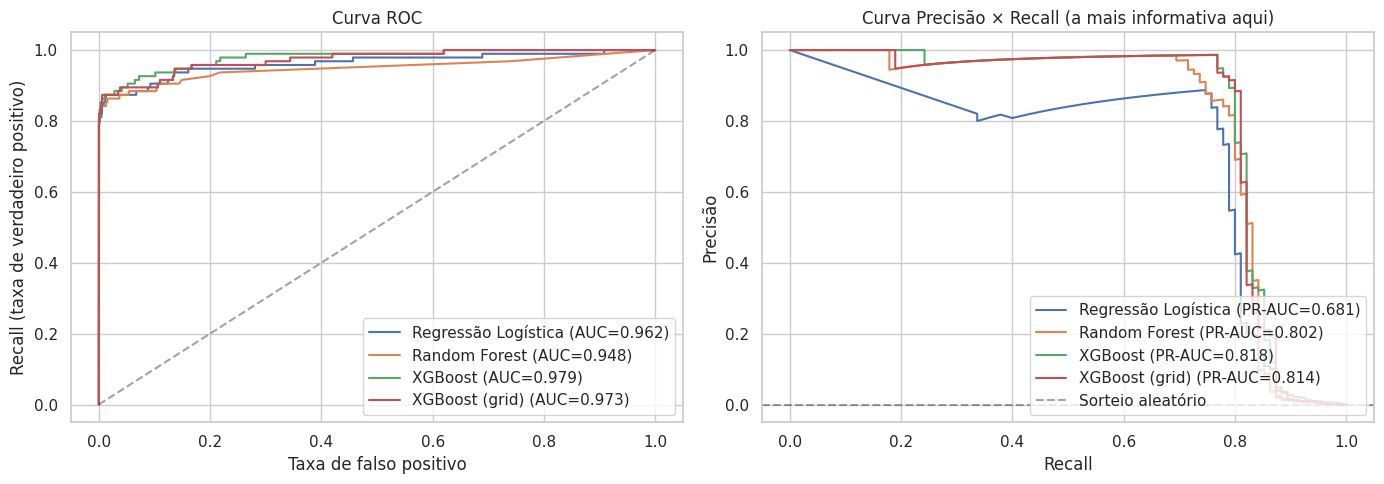

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for nome, p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    ax[0].plot(fpr, tpr, label=f"{nome} (AUC={roc_auc_score(y_test, p):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, p)
    ax[1].plot(rec, prec, label=f"{nome} (PR-AUC={average_precision_score(y_test, p):.3f})")
ax[0].plot([0, 1], [0, 1], "k--", alpha=.4)
ax[0].set(title="Curva ROC", xlabel="Taxa de falso positivo", ylabel="Recall (taxa de verdadeiro positivo)")
ax[1].axhline(y_test.mean(), color="k", ls="--", alpha=.4, label="Sorteio aleatório")
ax[1].set(title="Curva Precisão × Recall (a mais informativa aqui)", xlabel="Recall", ylabel="Precisão")
for a in ax: a.legend(loc="lower right")
plt.tight_layout()
salvar("03_curvas_roc_pr")
plt.show()

> A curva **ROC** tende a parecer ótima mesmo em modelos fracos quando há muitos negativos.
> A curva **Precisão × Recall** é mais honesta para fraude: mostra o custo (alertas falsos) de cada ganho de recall.

## 6. Ajuste do limiar de decisão

Por padrão, `predict` usa limiar 0,5, mas com classe rara esse quase nunca é o melhor ponto.

Para **não escolher o limiar olhando o teste** (isso seria vazamento), usamos previsões
**out-of-fold** (validação cruzada) no treino. Regra: entre os limiares que atingem o
`RECALL_ALVO`, escolher o de **maior precisão**.

Modelo escolhido: XGBoost
Previsões out-of-fold geradas em 71s
Limiar escolhido: 0.0315  (maior precisão com recall ≥ 85%)
Na validação cruzada -> recall=0.852 | precisão=0.706 | F1=0.772


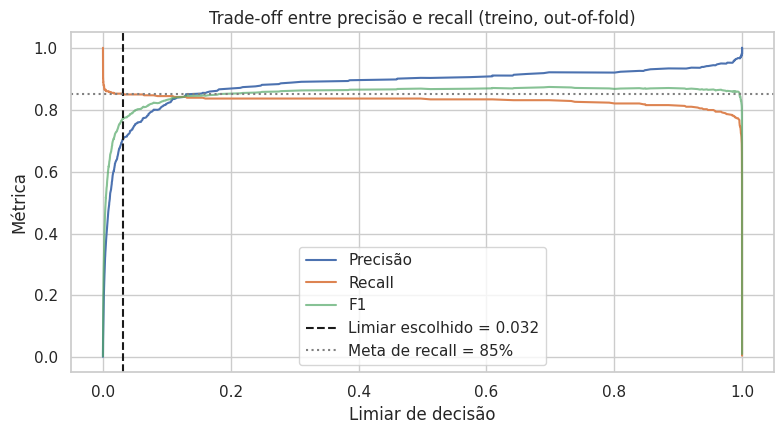

In [12]:
# Modelo final = melhor PR-AUC no teste (mais adiante, o ajuste do limiar NÃO usa o teste)
nome_final = tabela["pr_auc"].idxmax()
print("Modelo escolhido:", nome_final)

t0 = time.time()
oof = cross_val_predict(clone(modelos[nome_final]), X_train, y_train,
                        cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                        method="predict_proba", n_jobs=1)[:, 1]
print(f"Previsões out-of-fold geradas em {time.time() - t0:.0f}s")

prec, rec, thr = precision_recall_curve(y_train, oof)
prec, rec = prec[:-1], rec[:-1]                      # alinha com os limiares
f1s = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)

atinge_meta = rec >= RECALL_ALVO
if atinge_meta.any():
    idx = np.argmax(np.where(atinge_meta, prec, -1))
    criterio = f"maior precisão com recall ≥ {RECALL_ALVO:.0%}"
else:
    idx = np.argmax(f1s)
    criterio = "maior F1 (a meta de recall não foi atingida)"
LIMIAR = float(thr[idx])
print(f"Limiar escolhido: {LIMIAR:.4f}  ({criterio})")
print(f"Na validação cruzada -> recall={rec[idx]:.3f} | precisão={prec[idx]:.3f} | F1={f1s[idx]:.3f}")

plt.figure(figsize=(8, 4.5))
plt.plot(thr, prec, label="Precisão")
plt.plot(thr, rec, label="Recall")
plt.plot(thr, f1s, label="F1", alpha=.7)
plt.axvline(LIMIAR, color="k", ls="--", label=f"Limiar escolhido = {LIMIAR:.3f}")
plt.axhline(RECALL_ALVO, color="gray", ls=":", label=f"Meta de recall = {RECALL_ALVO:.0%}")
plt.xlabel("Limiar de decisão"); plt.ylabel("Métrica"); plt.title("Trade-off entre precisão e recall (treino, out-of-fold)")
plt.legend(); plt.tight_layout()
salvar("04_ajuste_limiar")
plt.show()

### 6.1 Resultado no teste: limiar 0,5 × limiar ajustado

,limiar,recall,precisão,f1,roc_auc,pr_auc
modelo,,,,,,
"XGBoost – limiar 0,5",0.5000,0.7895,0.9259,0.8523,0.9789,0.8175
XGBoost – limiar ajustado,0.0315,0.8211,0.6903,0.7500,0.9789,0.8175


              precision    recall  f1-score   support

      Normal     0.9997    0.9994    0.9995     56651
      Fraude     0.6903    0.8211    0.7500        95

    accuracy                         0.9991     56746
   macro avg     0.8450    0.9102    0.8748     56746
weighted avg     0.9992    0.9991    0.9991     56746



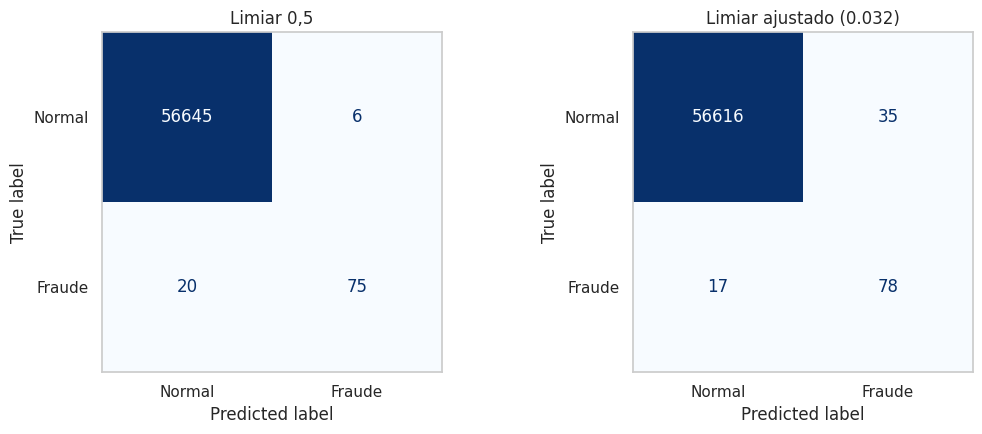

Fraudes detectadas: 78 de 95 | fraudes perdidas: 17 | alertas falsos: 35


In [13]:
p_final = probas[nome_final]
comparacao_limiar = pd.DataFrame([
    avaliar(f"{nome_final} – limiar 0,5", y_test, p_final, 0.5),
    avaliar(f"{nome_final} – limiar ajustado", y_test, p_final, LIMIAR),
]).set_index("modelo")
display(comparacao_limiar)

pred_final = (p_final >= LIMIAR).astype(int)
print(classification_report(y_test, pred_final, target_names=["Normal", "Fraude"], digits=4))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a, lim, tit in zip(ax, [0.5, LIMIAR], ["Limiar 0,5", f"Limiar ajustado ({LIMIAR:.3f})"]):
    ConfusionMatrixDisplay.from_predictions(y_test, (p_final >= lim).astype(int), ax=a,
                                            display_labels=["Normal", "Fraude"], cmap="Blues", colorbar=False)
    a.set_title(tit); a.grid(False)
plt.tight_layout()
salvar("05_matriz_confusao")
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, pred_final).ravel()
print(f"Fraudes detectadas: {tp} de {tp + fn} | fraudes perdidas: {fn} | alertas falsos: {fp}")

## 7. Undersampling x Oversampling x Peso de classes

Regra da Expert: **teste**. Implementamos as duas técnicas só com NumPy/pandas (sem depender de outra biblioteca):

- **Undersampling:** reduz as transações normais até igualar o nº de fraudes.
- **Oversampling:** repete fraudes (com reposição) até igualar o nº de normais.

A reamostragem é aplicada **somente no treino**. O teste continua com a proporção real.

In [14]:
def reamostrar(X_, y_, estrategia, seed=SEED):
    rng = np.random.default_rng(seed)
    pos = np.flatnonzero(y_.values == 1)
    neg = np.flatnonzero(y_.values == 0)
    if estrategia == "undersampling":
        neg = rng.choice(neg, size=len(pos), replace=False)
    elif estrategia == "oversampling":
        pos = rng.choice(pos, size=len(neg), replace=True)
    idx = rng.permutation(np.concatenate([pos, neg]))
    return X_.iloc[idx], y_.iloc[idx]

def novo_modelo(nome):
    if nome == "Regressão Logística":
        return LogisticRegression(max_iter=1000, random_state=SEED)
    return XGBClassifier(**{**PARAMS_XGB, "scale_pos_weight": 1})

linhas = []
for est in ["peso das classes", "undersampling", "oversampling"]:
    for nome in ["Regressão Logística", "XGBoost"]:
        if est == "peso das classes":
            modelo = modelos[nome]
        else:
            Xr, yr = reamostrar(X_train, y_train, est)
            modelo = novo_modelo(nome).fit(Xr, yr)
        r = avaliar(nome, y_test, modelo.predict_proba(X_test)[:, 1])
        r["estratégia"] = est
        linhas.append(r)

comp_resampling = (pd.DataFrame(linhas).set_index(["estratégia", "modelo"])
                   [["recall", "precisão", "f1", "pr_auc"]])
display(comp_resampling)

recall  precisão     f1  pr_auc
estratégia       modelo                                              
peso das classes Regressão Logística  0.8737    0.0547 0.1030  0.6810
                 XGBoost              0.7895    0.9259 0.8523  0.8175
undersampling    Regressão Logística  0.8737    0.0359 0.0689  0.4719
                 XGBoost              0.8632    0.0478 0.0906  0.7034
oversampling     Regressão Logística  0.8737    0.0549 0.1032  0.6809
                 XGBoost              0.7474    0.9342 0.8304  0.8110

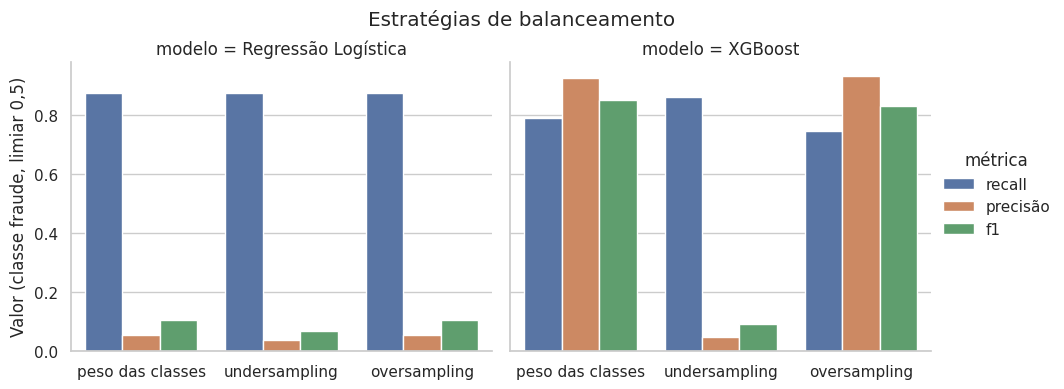

In [15]:
graf = comp_resampling.reset_index().melt(id_vars=["estratégia", "modelo"],
                                          value_vars=["recall", "precisão", "f1"], var_name="métrica")
g = sns.catplot(data=graf, x="estratégia", y="value", hue="métrica", col="modelo",
                kind="bar", height=4, aspect=1.2)
g.set_axis_labels("", "Valor (classe fraude, limiar 0,5)")
g.figure.suptitle("Estratégias de balanceamento", y=1.03)
salvar("06_comparacao_balanceamento")
plt.show()

**Como ler:** undersampling e oversampling costumam **aumentar o recall**, mas com queda forte de **precisão**
(muitos alertas falsos), porque o modelo passa a ver as fraudes como muito mais comuns do que são.
Compare com o peso de classes e decida pelo equilíbrio entre pegar fraudes e não incomodar clientes legítimos.

## 8. Explicar o modelo

### 8.1 Importância das variáveis

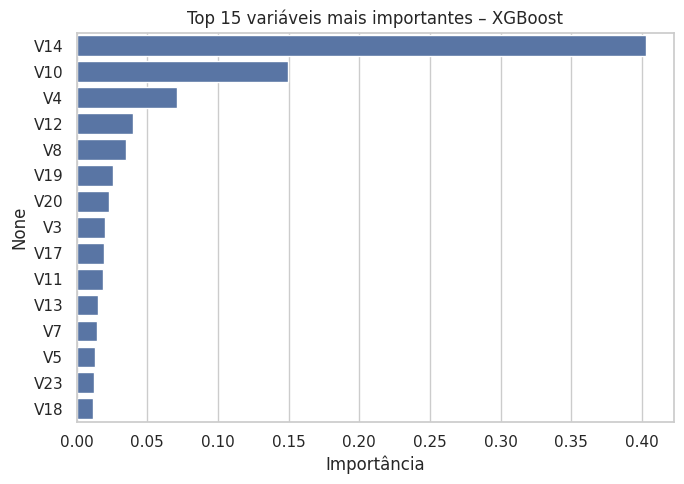

In [16]:
if nome_final.startswith("XGBoost"):
    modelo_shap, nome_shap = modelos[nome_final], nome_final
else:
    modelo_shap = modelos.get("XGBoost (grid)", modelos["XGBoost"])
    nome_shap = "XGBoost (grid)" if "XGBoost (grid)" in modelos else "XGBoost"
    print(f"O modelo final ({nome_final}) não é XGBoost; o SHAP abaixo usa {nome_shap}.")

imp = pd.Series(modelo_shap.feature_importances_, index=FEATURES).sort_values(ascending=False).head(15)
plt.figure(figsize=(7, 5))
sns.barplot(x=imp.values, y=imp.index, color="#4C72B0")
plt.title(f"Top 15 variáveis mais importantes – {nome_shap}")
plt.xlabel("Importância")
plt.tight_layout()
salvar("07_importancia_variaveis")
plt.show()

### 8.2 SHAP - o que pesou nas decisões

- **Beeswarm:** cada ponto é uma transação. Posição no eixo x = impacto na previsão (direita → empurra para "fraude"); cor = valor da variável.
- **Barras:** impacto médio absoluto de cada variável.
- **Waterfall:** explicação de **uma** transação fraudulenta específica.

Como as variáveis `V1`-`V28` vêm de PCA, elas não têm significado de negócio direto,
mas o SHAP mostra quais componentes mais separam fraude de transação normal.

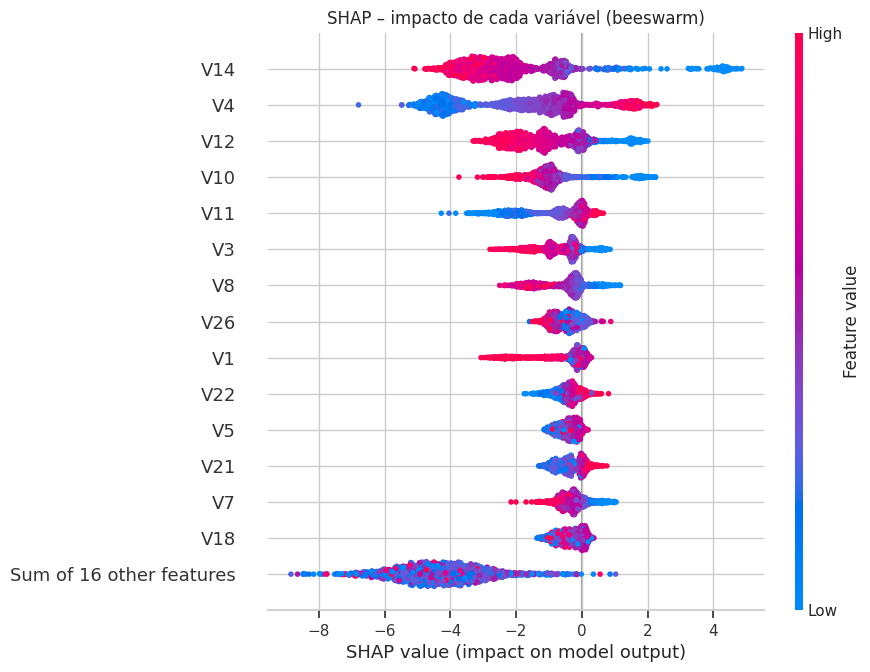

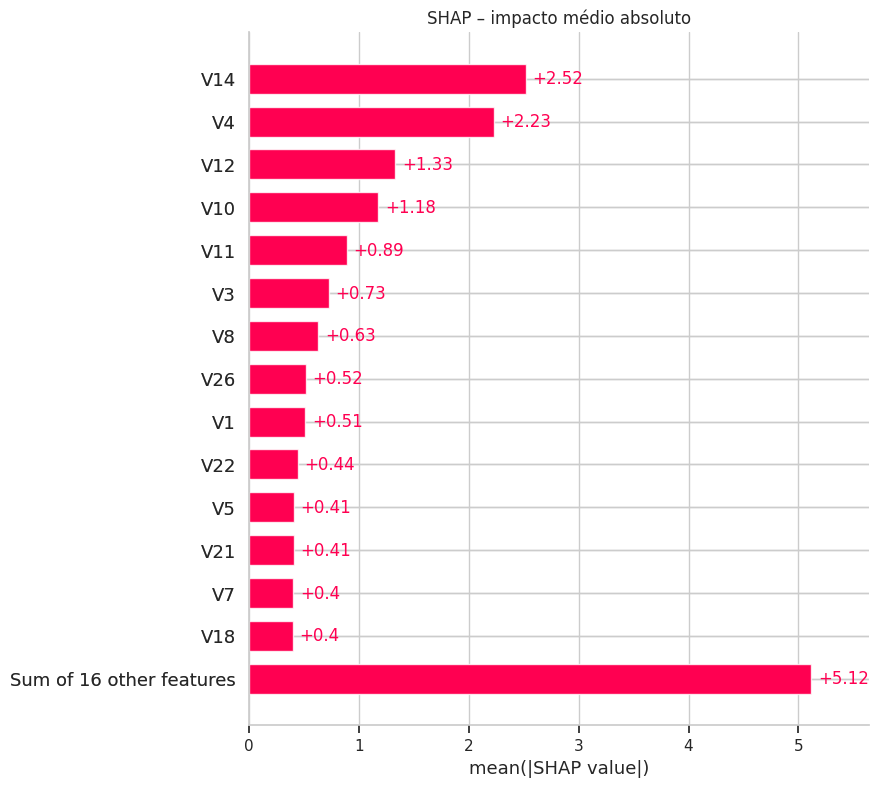

In [17]:
# Amostra: todas as fraudes do teste + 1.500 transações normais (para o gráfico ser legível e rápido)
rng = np.random.default_rng(SEED)
idx_fraude = X_test.index[y_test == 1]
idx_normal = rng.choice(X_test.index[y_test == 0], size=min(1500, (y_test == 0).sum()), replace=False)
X_shap = X_test.loc[np.concatenate([idx_fraude, idx_normal])]

explainer = shap.TreeExplainer(modelo_shap)
valores_shap = explainer(X_shap)

plt.figure()
shap.plots.beeswarm(valores_shap, max_display=15, show=False)
plt.title("SHAP – impacto de cada variável (beeswarm)")
salvar("08_shap_beeswarm")
plt.show()

plt.figure()
shap.plots.bar(valores_shap, max_display=15, show=False)
plt.title("SHAP – impacto médio absoluto")
salvar("09_shap_barras")
plt.show()

Transação de teste #115676 | probabilidade de fraude = 0.9999


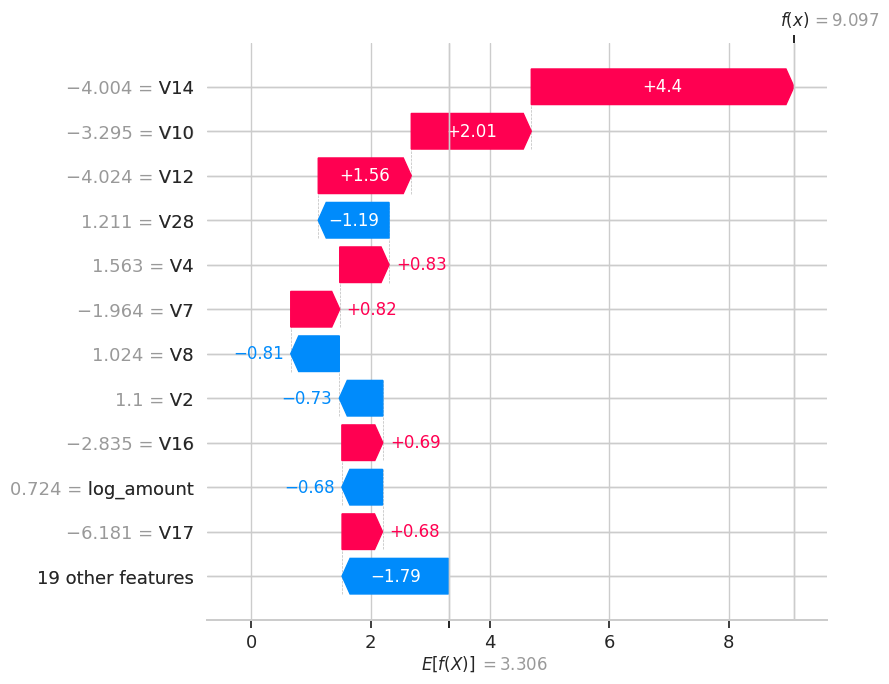

In [18]:
# Explicação de UMA fraude real que o modelo detectou (true positive)
detectadas = X_test.index[(y_test.values == 1) & (p_final >= LIMIAR)]
i_exemplo = detectadas[0]
print(f"Transação de teste #{i_exemplo} | probabilidade de fraude = {p_final[X_test.index.get_loc(i_exemplo)]:.4f}")

shap_um = explainer(X_test.loc[[i_exemplo]])
plt.figure()
shap.plots.waterfall(shap_um[0], max_display=12, show=False)
salvar("10_shap_waterfall_fraude")
plt.show()

## 9. Resumo e resultados salvos

In [19]:
tabela_final = pd.concat([
    tabela.drop(columns="limiar"),
    comparacao_limiar.drop(columns="limiar").iloc[[1]],
]).round(4)
display(tabela_final)

tabela_final.to_csv("resultados/comparacao_modelos.csv")
comp_resampling.round(4).to_csv("resultados/comparacao_balanceamento.csv")

print(f"\nModelo final : {nome_final}")
print(f"Limiar       : {LIMIAR:.4f}  ({criterio})")
r = comparacao_limiar.iloc[1]
print(f"No teste     : recall={r['recall']:.3f} | precisão={r['precisão']:.3f} | F1={r['f1']:.3f} | PR-AUC={r['pr_auc']:.3f}")

# Tabela pronta para colar no README
try:
    print("\n--- Cole no README ---\n")
    print(tabela_final[["recall", "precisão", "f1", "roc_auc", "pr_auc"]].to_markdown())
except ImportError:
    pass

,recall,precisão,f1,roc_auc,pr_auc
modelo,,,,,
Regressão Logística,0.8737,0.0547,0.1030,0.9623,0.6810
Random Forest,0.7368,0.9333,0.8235,0.9483,0.8018
XGBoost,0.7895,0.9259,0.8523,0.9789,0.8175
XGBoost (grid),0.7895,0.9146,0.8475,0.9730,0.8142
XGBoost – limiar ajustado,0.8211,0.6903,0.7500,0.9789,0.8175



Modelo final : XGBoost
Limiar       : 0.0315  (maior precisão com recall ≥ 85%)
No teste     : recall=0.821 | precisão=0.690 | F1=0.750 | PR-AUC=0.818

--- Cole no README ---

| modelo                    |   recall |   precisão |     f1 |   roc_auc |   pr_auc |
|:--------------------------|---------:|-----------:|-------:|----------:|---------:|
| Regressão Logística       |   0.8737 |     0.0547 | 0.103  |    0.9623 |   0.681  |
| Random Forest             |   0.7368 |     0.9333 | 0.8235 |    0.9483 |   0.8018 |
| XGBoost                   |   0.7895 |     0.9259 | 0.8523 |    0.9789 |   0.8175 |
| XGBoost (grid)            |   0.7895 |     0.9146 | 0.8475 |    0.973  |   0.8142 |
| XGBoost – limiar ajustado |   0.8211 |     0.6903 | 0.75   |    0.9789 |   0.8175 |


## 10. Conclusões

- **Acurácia é enganosa:** o modelo "sempre normal" tem ~99,8% de acurácia e recall 0.
- **Métrica-guia:** recall da fraude, sempre acompanhado de precisão e F1 (e PR-AUC para comparar modelos).
- **Modelos:** compare a tabela da seção 5 - normalmente os modelos de árvores (Random Forest/XGBoost) superam o baseline linear em precisão para o mesmo recall.
- **Limiar:** ajustá-lo (com validação cruzada, sem olhar o teste) permite escolher conscientemente o equilíbrio entre fraudes perdidas e alertas falsos.
- **Balanceamento:** undersampling/oversampling elevam o recall, mas custam precisão; o peso de classes costuma dar um equilíbrio melhor.
- **Explicabilidade:** o SHAP mostra quais componentes (`V*`) e variáveis derivadas mais empurram cada transação para "fraude".

**Limitações e próximos passos**

- A escolha do modelo final usa o PR-AUC do teste; o ideal seria um conjunto de validação separado.
- Não há dimensão temporal real (split aleatório); em produção, valide por período.
- Ideias: features de sequência de transações, busca de hiperparâmetros maior, custo financeiro por erro (fraude perdida x alerta falso), outros modelos (LightGBM, CatBoost).